# Anomalous Authentication Behavior Detection
## AI/ML Capstone Project — Daisy Wu

This notebook walks through the complete analysis pipeline for detecting anomalous
authentication behavior in enterprise security logs using the **LANL Cyber Security Dataset**.

### Pipeline Overview

1. **Setup and Imports**
2. **Data Loading and Preprocessing**
3. **Exploratory Data Analysis**
4. **Feature Engineering**
5. **PCA and Clustering**
6. **Time Series Analysis**
7. **Data Preparation & SMOTE**
8. **Classification: KNN and Logistic Regression**
9. **Decision Trees, Random Forest, & SVM**
10. **Hyperparameter Tuning with GridSearchCV**
11. **SHAP Value Analysis for Model Interpretability**
12. **Final Model Comparison**
13. **Conclusions and Next Steps**


## 1. Setup and Imports

In [7]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_preprocessing import (
    load_auth_data, load_auth_data_sampled, load_redteam_labels,
    clean_data, label_redteam_events, save_processed_data
)
from src.feature_engineering import build_feature_matrix, FEATURE_COLUMNS, TARGET_COLUMN
from src.eda import (
    generate_summary_statistics, run_full_eda,
    plot_login_distribution, plot_success_failure_ratio,
    plot_hourly_pattern, plot_top_users,
    plot_auth_type_distribution, plot_redteam_timeline,
    plot_correlation_matrix
)
from src.clustering_pca import (
    apply_pca, plot_explained_variance,
    find_optimal_clusters, apply_kmeans, plot_pca_clusters
)
from src.time_series import (
    aggregate_login_timeseries, decompose_timeseries,
    detect_temporal_anomalies, plot_timeseries_with_anomalies
)
from src.model_selection import (
    compare_models, tune_regularization,
    plot_learning_curve, evaluate_model, save_model
)
from src.classification import (
    train_knn, find_optimal_k, train_logistic_regression,
    plot_roc_curves, plot_confusion_matrices, print_classification_report
)
from src.decision_trees import (
    train_decision_tree, tune_tree_depth,
    visualize_tree, extract_rules, get_feature_importance
)
from src.utils import load_processed_data, prepare_train_test, print_section

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.max_columns', 50)

print('All imports successful!')

All imports successful!


## 2. Data Loading and Preprocessing

The LANL dataset contains ~1.6 billion authentication events over 58 days.
We start with a sample for development, then scale up.

**Before running:** Download the LANL dataset and place `auth.txt.gz` and `redteam.txt.gz` in `data/raw/`.

In [8]:
# Load a stratified sample spread across the full 58-day time range.
# This ensures we capture red team events and have enough temporal coverage
# for time series analysis. Adjust target_rows to trade speed vs. coverage.
SAMPLE_SIZE = 1_000_000

df_raw = load_auth_data_sampled(target_rows=SAMPLE_SIZE)
df_raw.head(10)

Loading stratified sample (~1,000,000 rows, rate=0.000607) from /Users/dw733324/gh-ws/MLAI-Capstone-Project/data/raw/auth.txt.gz...
Loading red team labels from /Users/dw733324/gh-ws/MLAI-Capstone-Project/data/raw/redteam.txt.gz...
  Loaded 749 red team events
  ... processed 100M rows, collected 60,706 so far
  ... processed 200M rows, collected 121,636 so far
  ... processed 300M rows, collected 182,629 so far
  ... processed 400M rows, collected 243,295 so far
  ... processed 500M rows, collected 303,995 so far
  ... processed 600M rows, collected 364,662 so far


KeyboardInterrupt: 

In [ ]:
# Load red team labels (known malicious events)
redteam = load_redteam_labels()
print(f"\nRed team event sample:")
redteam.head()

Loading red team labels from /Users/dw733324/gh-ws/MLAI-Capstone-Project/data/raw/redteam.txt.gz...
  Loaded 749 red team events

Red team event sample:


,time,src_user_domain,src_computer,dst_computer
0,150885,U620@DOM1,C17693,C1003
1,151036,U748@DOM1,C17693,C305
2,151648,U748@DOM1,C17693,C728
3,151993,U6115@DOM1,C17693,C1173
4,153792,U636@DOM1,C17693,C294


In [ ]:
# Clean the data: parse user@domain, convert success/failure, add time features
df = clean_data(df_raw)
df.head()

  Cleaned data: 638,499 rows, 19 columns


,time,src_user_domain,dst_user_domain,src_computer,dst_computer,auth_type,logon_type,auth_orientation,outcome,src_user,src_domain,dst_user,dst_domain,success,hour,day,day_of_week,is_off_hours,is_weekend
0,3,C1297$@DOM1,SYSTEM@C1297,C1297,C1297,Negotiate,Service,LogOn,Success,C1297$,DOM1,SYSTEM,C1297,1,0,0,0,1,0
1,4,C1381$@DOM1,SYSTEM@C1381,C1381,C1381,Negotiate,Service,LogOn,Success,C1381$,DOM1,SYSTEM,C1381,1,0,0,0,1,0
2,10,U66@DOM1,U66@DOM1,C1998,C1998,NaN,Network,LogOff,Success,U66,DOM1,U66,DOM1,1,0,0,0,1,0
3,14,U75@DOM1,U75@DOM1,C1710,C1710,NaN,Interactive,LogOff,Success,U75,DOM1,U75,DOM1,1,0,0,0,1,0
4,33,C357$@DOM1,C357$@DOM1,C612,C612,NaN,Network,LogOff,Success,C357$,DOM1,C357$,DOM1,1,0,0,0,1,0


In [ ]:
# Label red team events as suspicious
df = label_redteam_events(df, redteam)

# Save cleaned data for reuse
save_processed_data(df, 'auth_cleaned.parquet')

  Labeled 702 suspicious events (0.1099% of total)
  Saved 638,499 rows to /Users/dw733324/gh-ws/MLAI-Capstone-Project/data/processed/auth_cleaned.parquet


In [ ]:
# load data from parquet file
df = load_processed_data('auth_cleaned.parquet')

## 3. Exploratory Data Analysis

In [ ]:
# Summary statistics
generate_summary_statistics(df)

Dataset shape: (638499, 20)

Time range: 3 – 5011199 seconds
Duration: 58.0 days

Unique source users: 22,249
Unique destination users: 22,228
Unique source computers: 13,501
Unique destination computers: 11,720

Authentication types: {'Kerberos': 220069, 'Negotiate': 33358, 'NTLM': 30868, 'MICROSOFT_AUTHENTICATION_PACKAGE_V1_0': 457, 'MICROSOFT_AUTHENTICATION_PACKAG': 15, 'MICROSOFT_AUTHENTICATION_PACKAGE': 14, 'MICROSOFT_AUTHENTICATION_PACKAGE_V1_': 12, 'MICROSOFT_AUTHENTICATION_PACK': 12, 'MICROSOFT_AUTHENTICATION_PACKAGE_V1': 8, 'MICROSOFT_AUTHENTICATION_PACKAGE_V': 4, 'MICROSOFT_AUTHENTICATION_PACKAGE_': 4, 'MICROSOFT_AUTHENTICATION_PA': 2, 'ACRONIS_RELOGON_AUTHENTICATION_PACKAGE': 1, 'MICROSOFT_AUTHENTICATION_PACKA': 1}
Logon types: {'Network': 514066, 'Service': 29621, 'Unlock': 2344, 'Interactive': 1275, 'Batch': 1065, 'NewCredentials': 665, 'NetworkCleartext': 238, 'RemoteInteractive': 83, 'CachedInteractive': 70}

Outcome distribution:
outcome
Success    630828
Fail         7

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_daily_volume.png


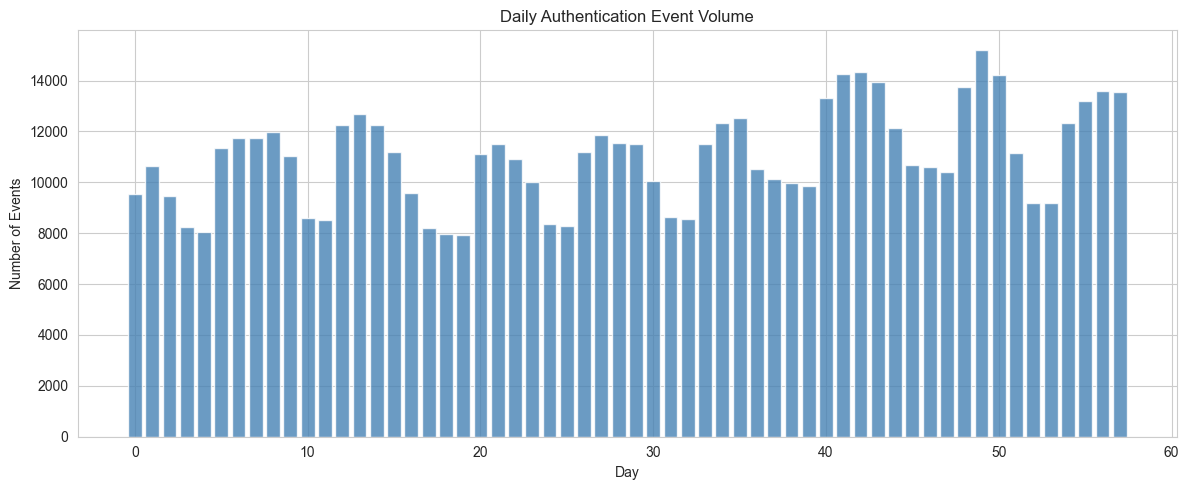

In [ ]:
# Login volume over time
plot_login_distribution(df)

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_success_failure.png


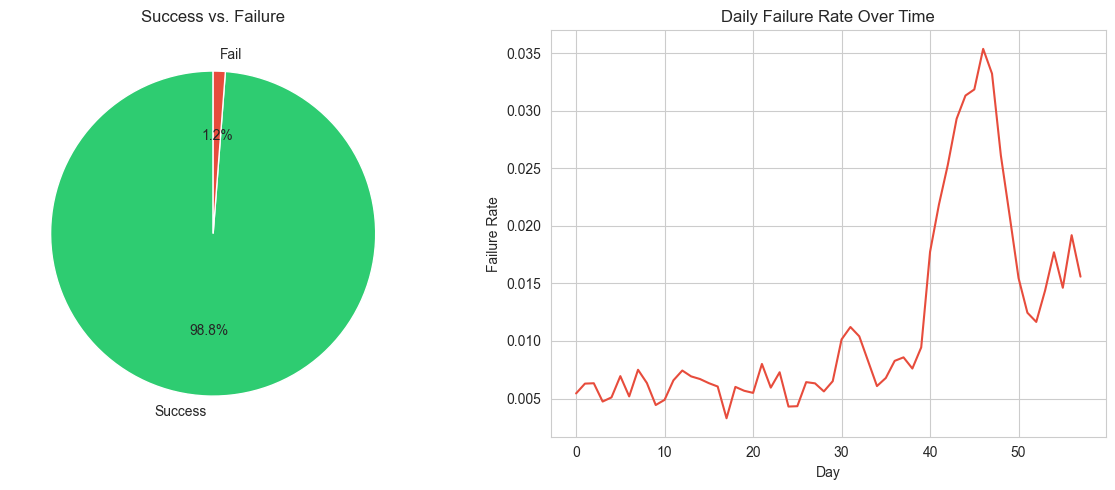

In [ ]:
# Success vs. failure breakdown
plot_success_failure_ratio(df)

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_hourly_pattern.png


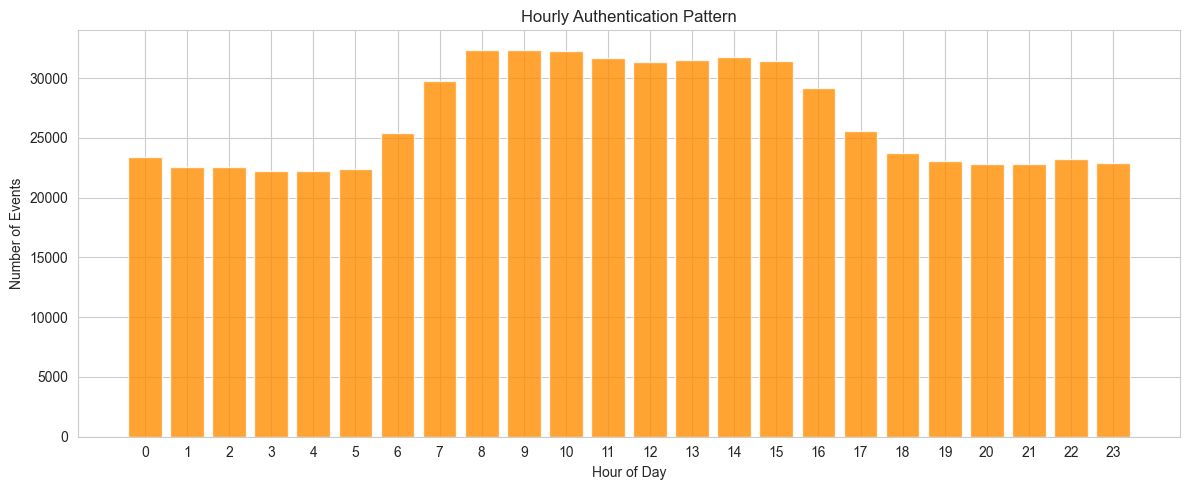

In [ ]:
# Hourly login pattern
plot_hourly_pattern(df)

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_top_users.png


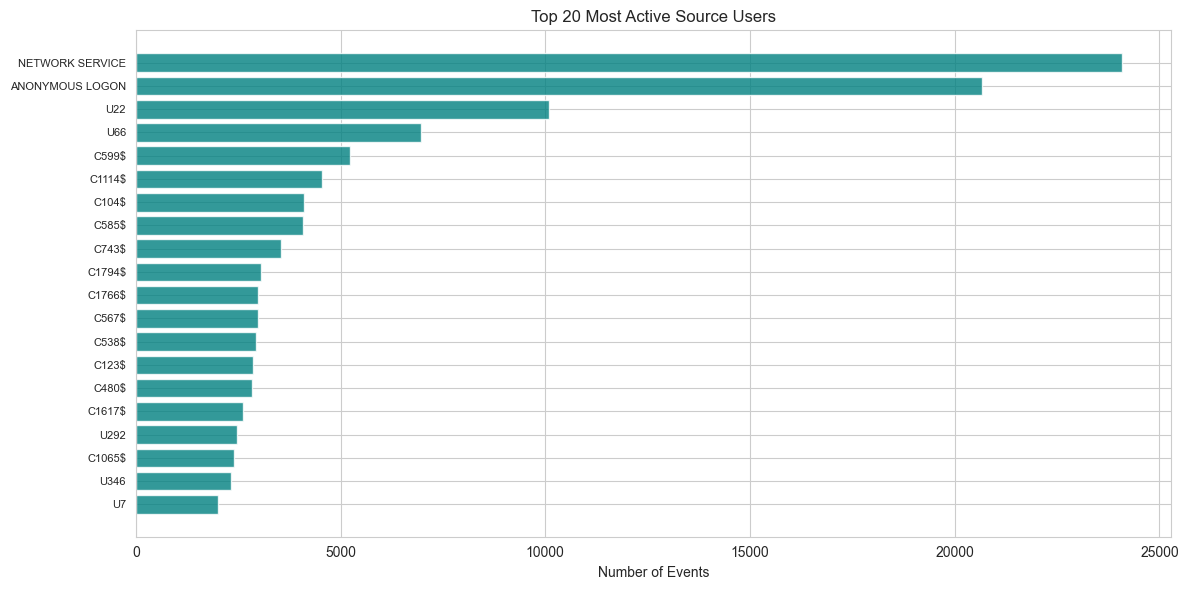

In [ ]:
# Most active users
plot_top_users(df, top_n=20)

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_auth_types.png


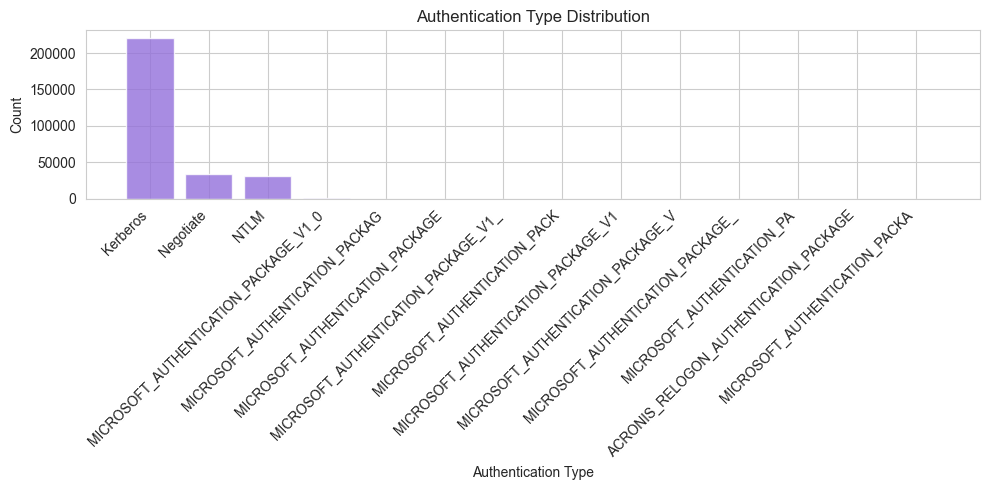

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_logon_types.png


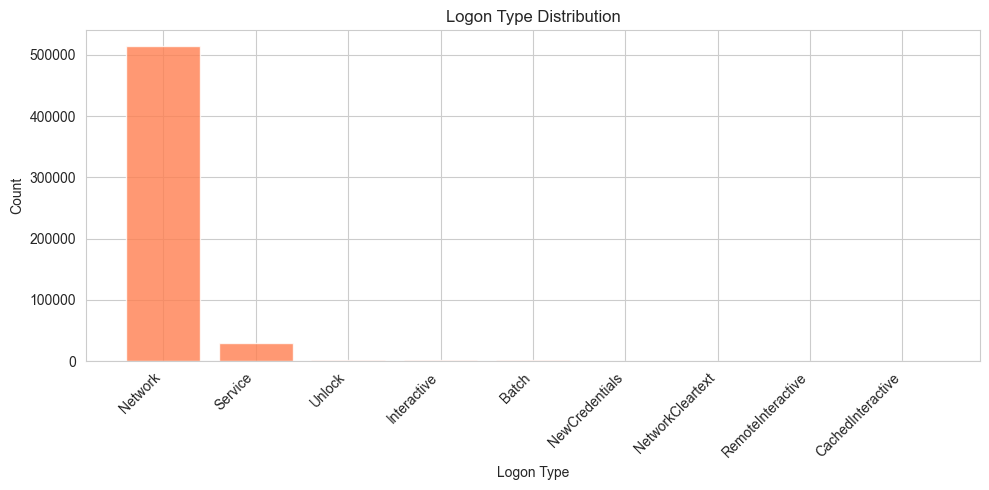

In [ ]:
# Authentication and logon type distributions
plot_auth_type_distribution(df)
from src.eda import plot_logon_type_distribution
plot_logon_type_distribution(df)

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_redteam_timeline.png


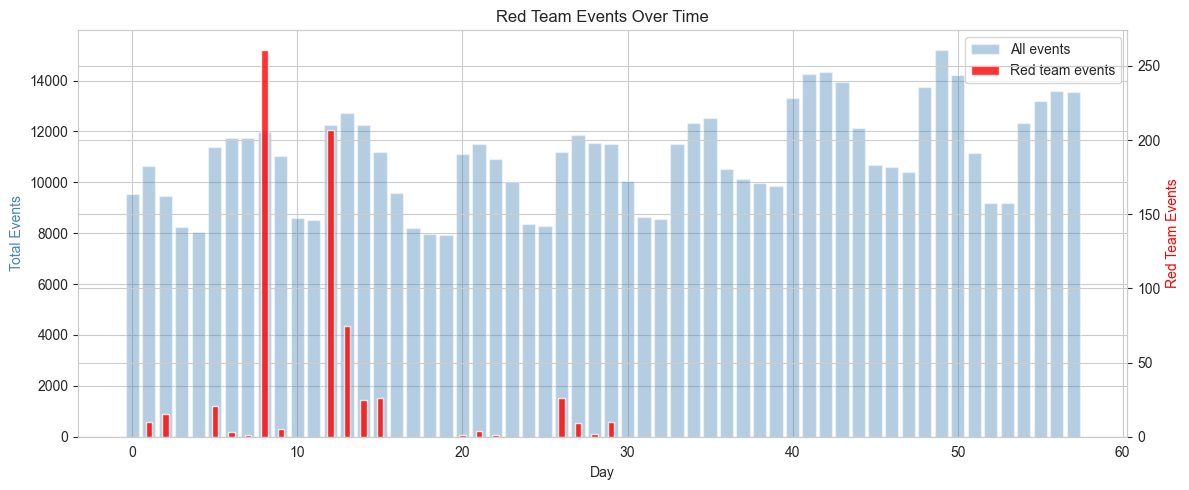

In [ ]:
# Red team events timeline
plot_redteam_timeline(df)

## 4. Feature Engineering

Engineer behavioral features from raw log fields:

- **Temporal**: hour, day, off-hours flag, weekend flag, time since last login
- **Frequency**: login counts over 1h/6h/24h windows, daily failure ratio
- **Diversity**: distinct computers, auth types, logon types per user per day
- **Baseline**: total events, mean daily events, new destination flag

In [ ]:
print("Building feature matrix (this may take a few minutes)...")
df_features = build_feature_matrix(df)
df_features.head(10)

Building feature matrix (this may take a few minutes)...
  Computing rolling login counts (1h, 6h, 24h)...
  Computing failure counts and ratios...
  Computing diversity features (unique computers, auth types)...
  Computing time-since-last-login...
  Computing new-destination flag...
  Computing velocity (events per minute, 10-min window)...
  Feature matrix: 638,499 rows × 17 columns
  Suspicious events: 702 (0.1099%)


,hour,day_of_week,is_off_hours,is_weekend,success,login_count_1h,login_count_6h,login_count_24h,fail_count_1h,fail_ratio_24h,unique_dst_computers_24h,unique_auth_types_24h,unique_logon_types_24h,time_since_last_login,is_new_dst_computer,events_per_minute_10m,is_suspicious
0,0,0,1,0,1,1,1,1,0,0.0,1,1,1,0.0,1,0.1,0
1,0,0,1,0,1,1,1,1,0,0.0,3,1,2,0.0,1,0.1,0
2,0,0,1,0,1,1,1,1,0,0.0,58,2,1,0.0,1,0.1,0
3,0,0,1,0,1,1,1,1,0,0.0,2,0,2,0.0,1,0.1,0
4,0,0,1,0,1,1,1,1,0,0.0,2,0,1,0.0,1,0.1,0
5,0,0,1,0,1,1,1,1,0,0.0,1,0,1,0.0,1,0.1,0
6,0,0,1,0,1,1,1,1,0,0.0,2,1,1,0.0,1,0.1,0
7,0,0,1,0,1,1,1,1,0,0.0,3,3,2,0.0,1,0.1,0
8,0,0,1,0,1,1,1,1,0,0.0,3,1,1,0.0,1,0.1,0
9,0,0,1,0,1,1,1,1,0,0.0,1,0,1,0.0,1,0.1,0


In [ ]:
# Save feature matrix for reuse
save_processed_data(df_features, 'auth_features.parquet')

print(f"\nFeature columns: {[c for c in df_features.columns if c != TARGET_COLUMN]}")
print(f"Target column: {TARGET_COLUMN}")
print(f"\nClass distribution:")
print(df_features[TARGET_COLUMN].value_counts())

  Saved 638,499 rows to /Users/dw733324/gh-ws/MLAI-Capstone-Project/data/processed/auth_features.parquet

Feature columns: ['hour', 'day_of_week', 'is_off_hours', 'is_weekend', 'success', 'login_count_1h', 'login_count_6h', 'login_count_24h', 'fail_count_1h', 'fail_ratio_24h', 'unique_dst_computers_24h', 'unique_auth_types_24h', 'unique_logon_types_24h', 'time_since_last_login', 'is_new_dst_computer', 'events_per_minute_10m']
Target column: is_suspicious

Class distribution:
is_suspicious
0    637797
1       702
Name: count, dtype: int64


  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/eda_correlation_matrix.png


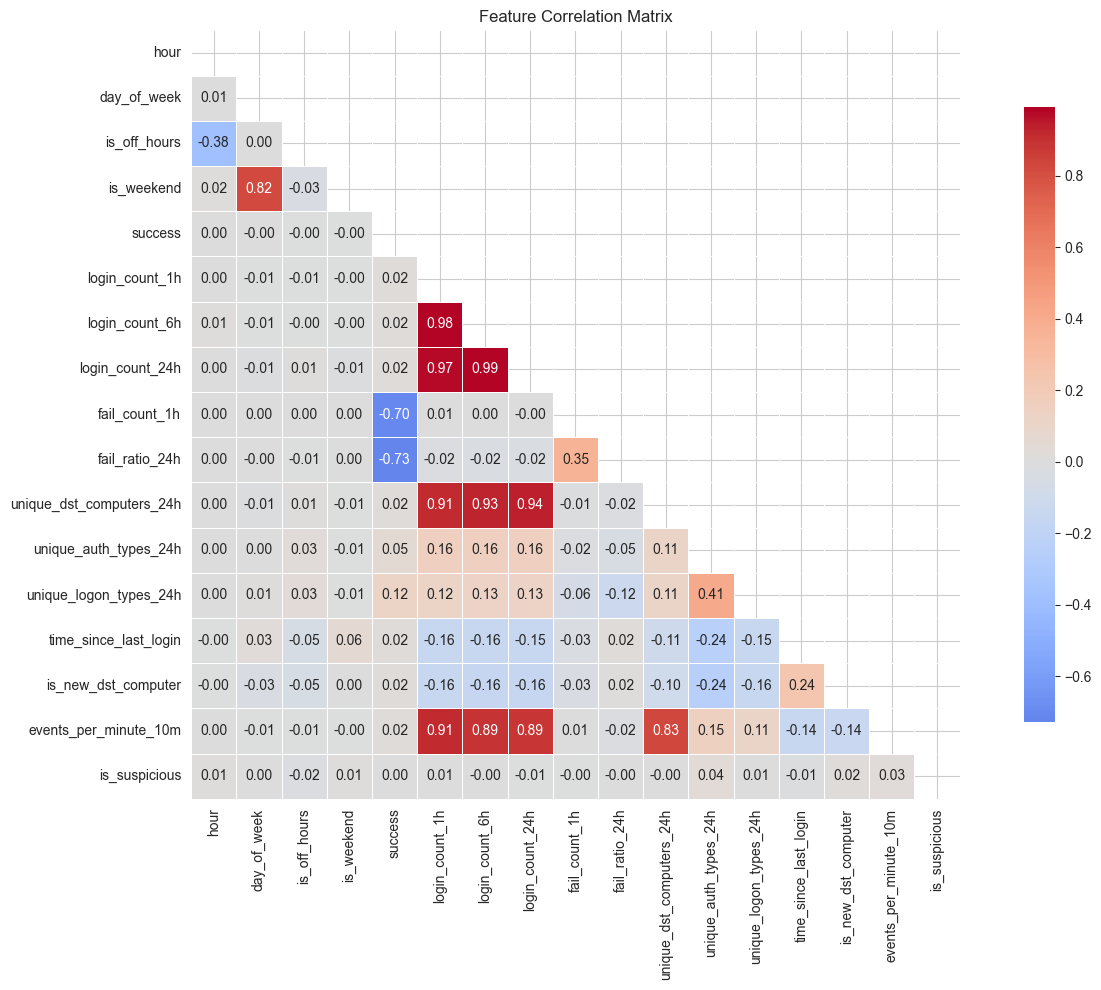

In [ ]:
# Correlation matrix of engineered features
plot_correlation_matrix(df_features)

## 5. PCA and Clustering

Use PCA to reduce the high-dimensional feature space for visualization.
Apply K-Means clustering to discover natural groupings of login behavior.

In [ ]:
# Separate features and target
X_all = df_features.drop(columns=[TARGET_COLUMN]).values
y_all = df_features[TARGET_COLUMN].values
feature_names = [c for c in df_features.columns if c != TARGET_COLUMN]

# Explained variance analysis
plot_explained_variance(X_all)

NameError: name 'df_features' is not defined

In [ ]:
# Apply PCA (2 components for visualization)
X_pca, pca, pca_scaler = apply_pca(X_all, n_components=2)

  PCA: 16 features → 2 components
  Explained variance: 0.4416


  K=2: inertia=1909990, silhouette=0.9010
  K=3: inertia=637105, silhouette=0.9194
  K=4: inertia=330096, silhouette=0.8014
  K=5: inertia=246141, silhouette=0.8026
  K=6: inertia=181336, silhouette=0.6048
  K=7: inertia=147115, silhouette=0.5310
  K=8: inertia=121354, silhouette=0.5194
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/clustering_elbow_silhouette.png


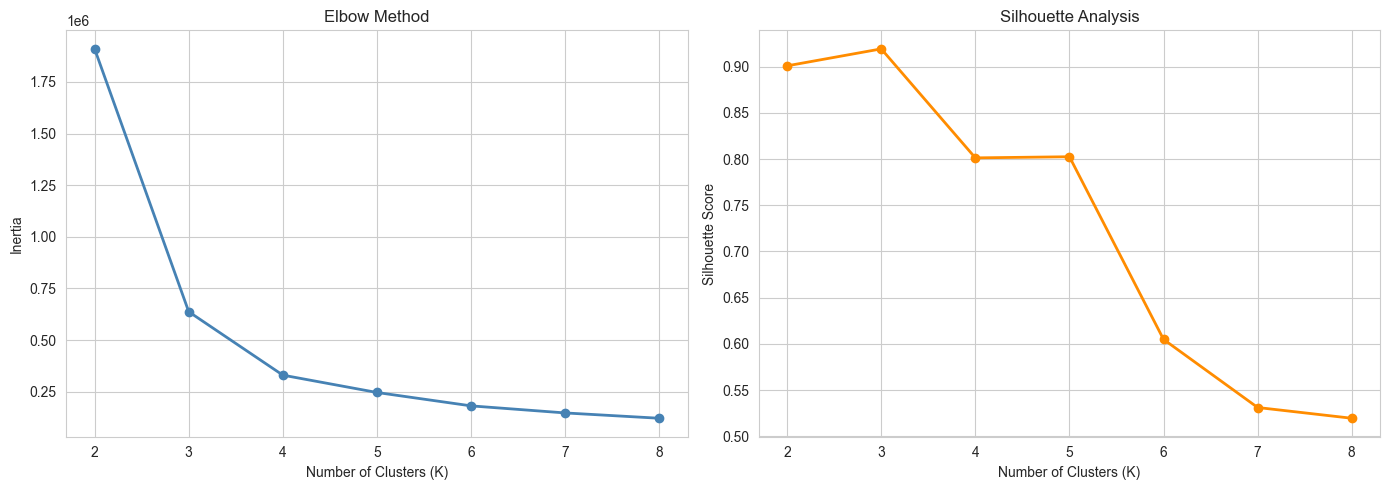

In [ ]:
# Find optimal number of clusters
K_range, inertias, silhouettes = find_optimal_clusters(X_pca, max_k=8)

  K-Means (K=3): silhouette=0.9163
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/pca_clusters.png


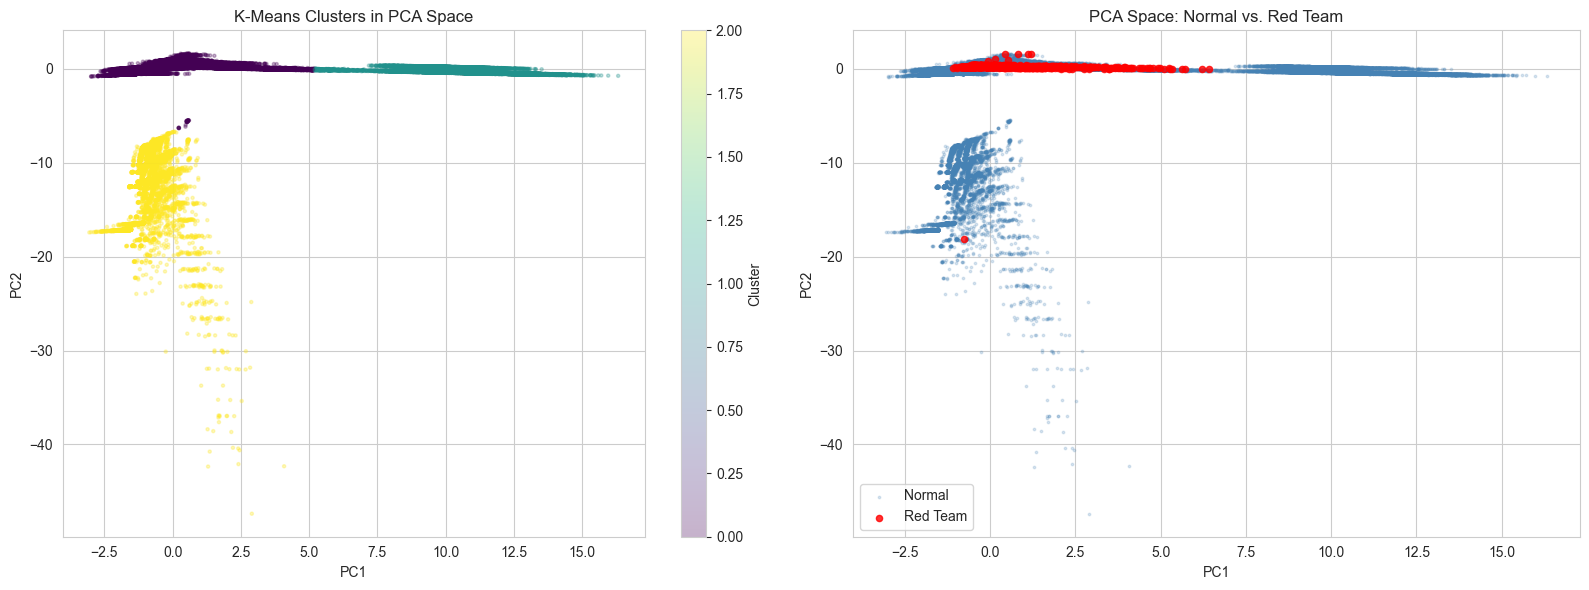

In [ ]:
# Apply K-Means and visualize with red team overlay
labels, kmeans = apply_kmeans(X_pca, n_clusters=3)
plot_pca_clusters(X_pca, labels, suspicious=y_all)

In [ ]:
# Analyze cluster composition
cluster_df = pd.DataFrame({'cluster': labels, 'is_suspicious': y_all})
print("Cluster composition:")
print(cluster_df.groupby('cluster')['is_suspicious'].agg(['count', 'sum', 'mean']))
print("\n'mean' = proportion of red team events in each cluster")

Cluster composition:
          count  sum      mean
cluster                       
0        609080  694  0.001139
1         21777    7  0.000321
2          7642    1  0.000131

'mean' = proportion of red team events in each cluster


## 6. Time Series Analysis
Model temporal trends in login behavior and detect sudden deviations.

In [ ]:
# Aggregate to hourly time series
ts = aggregate_login_timeseries(df, freq_seconds=3600)
print(f"Time series: {len(ts)} hourly bins")
print(f"Mean events/hour: {ts.mean():.0f}")
print(f"Max events/hour: {ts.max():.0f}")

Time series: 1392 hourly bins
Mean events/hour: 459
Max events/hour: 1069


  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/ts_decomposition.png


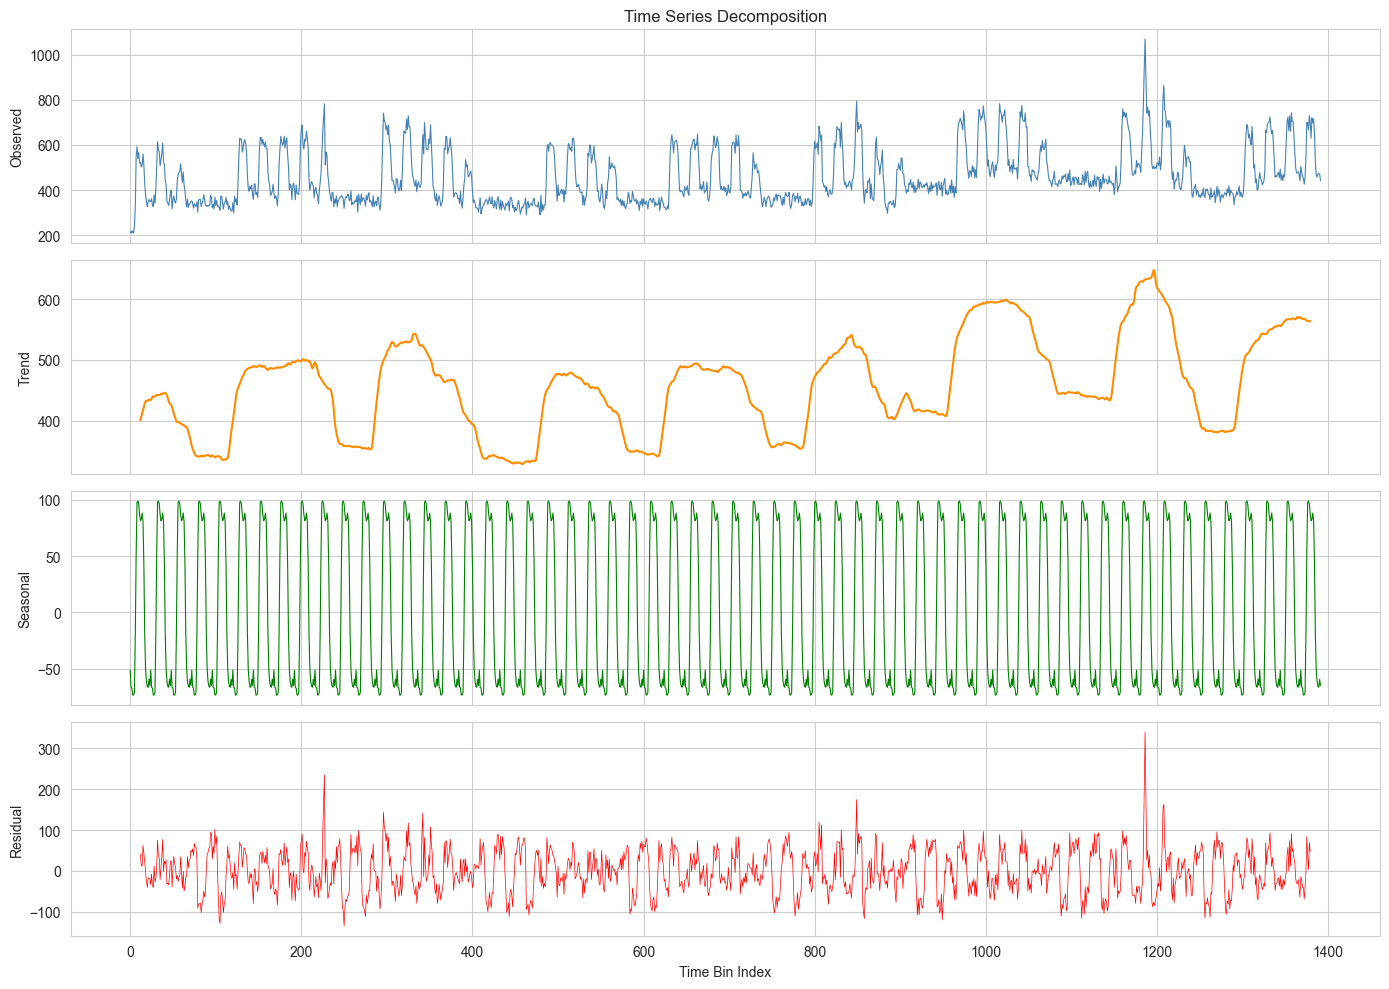

In [ ]:
# Seasonal decomposition (daily seasonality = 24 hours)
decomposition = decompose_timeseries(ts, period=24)

  Detected 0 anomalous time bins (threshold=3.0, window=24)
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/ts_anomalies.png


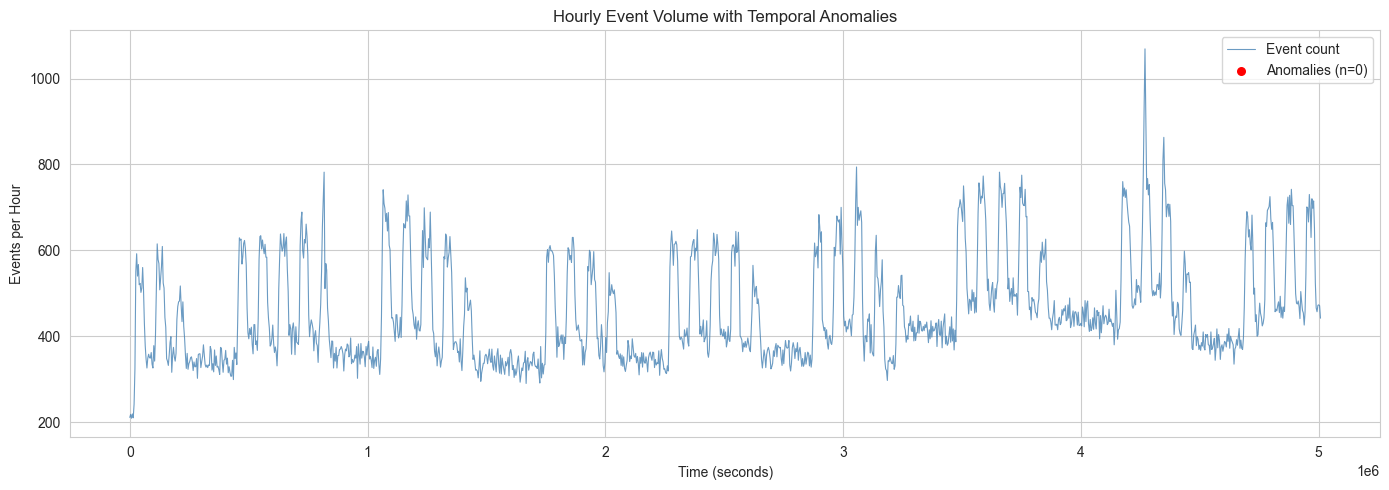

In [ ]:
# Detect temporal anomalies using z-score
anomalies = detect_temporal_anomalies(ts, window=24, threshold=3.0)
plot_timeseries_with_anomalies(ts, anomalies)

## 7. Data Preparation & SMOTE

Before training our models, we need to split the data into training and test sets and scale the features. Because our dataset is extremely imbalanced (~0.1% positive class), we apply the **SMOTE (Synthetic Minority Over-sampling Technique)** strategy to the training data. SMOTE synthesizes new examples for the minority class (red team events) by interpolating between existing positive samples, which helps the models learn the minority class better without simply memorizing duplicated rows.

In [ ]:
# Prepare train/test split, scale features, and apply SMOTE to the training set
X_train, X_test, y_train, y_test, scaler, feat_names = prepare_train_test(df_features, apply_smote=True)

  Train: 510,799 rows (562 positive)
  Test:  127,700 rows (140 positive)


Cross-validation model comparison:


/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow enc

  Logistic Regression (L2): AUC = 0.9602 ± 0.0023


/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encoun

  Logistic Regression (L1): AUC = 0.9602 ± 0.0023
  KNN (k=5): AUC = 0.7348 ± 0.0175
  Decision Tree (depth=5): AUC = 0.9391 ± 0.0043
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/model_comparison_cv.png


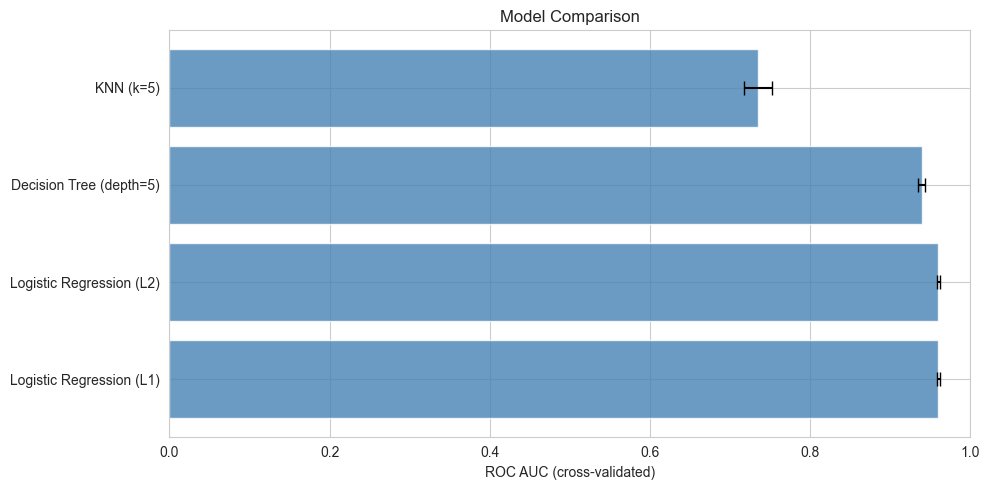

In [ ]:
# Compare all candidate models
print("Cross-validation model comparison:")
results = compare_models(X_train, y_train, cv=5)

/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow enc

  Best C = 1438.449888 (AUC = 0.9602)
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/regularization_tuning.png


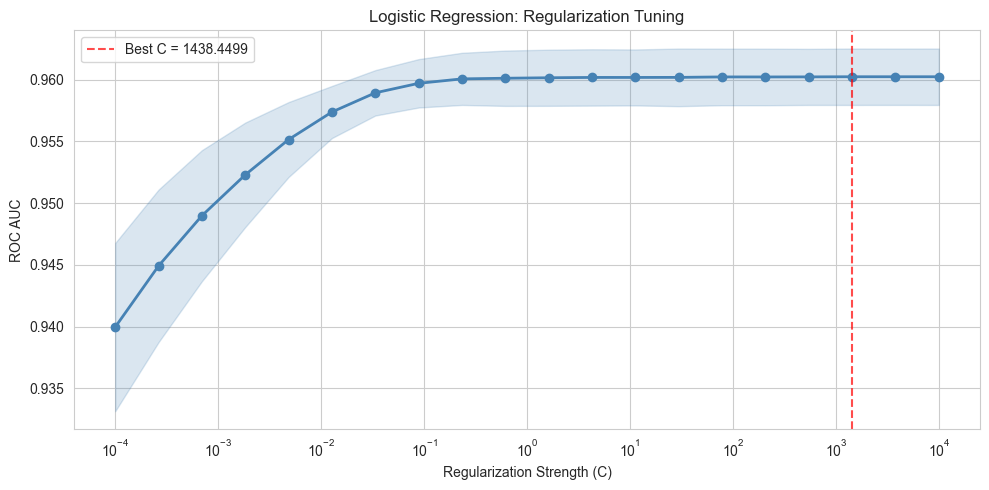

In [ ]:
# Tune regularization (C parameter) for logistic regression
best_lr, reg_results = tune_regularization(X_train, y_train, cv=5)

/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/dw733324/gh-ws/MLAI-Capstone-Project/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: 

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/learning_curve.png


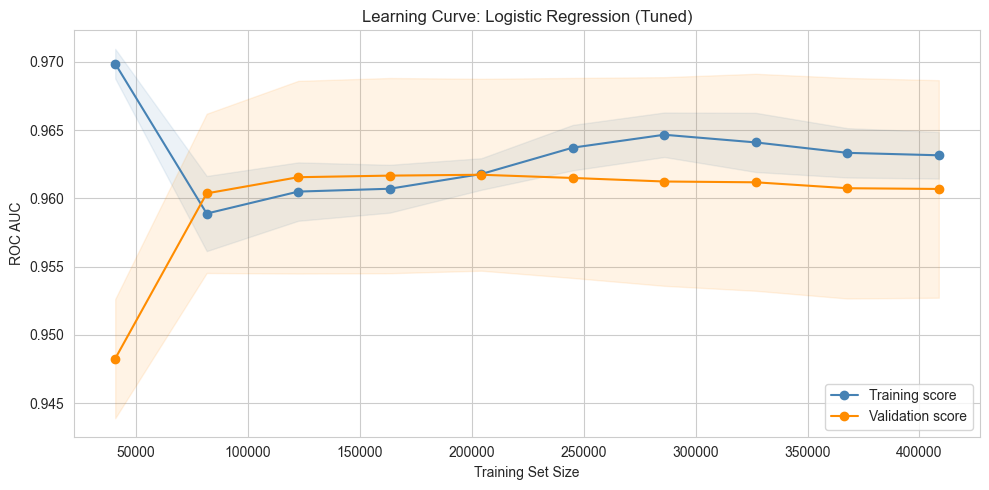

In [ ]:
# Learning curve for the tuned logistic regression
plot_learning_curve(best_lr, X_train, y_train, 'Logistic Regression (Tuned)')

## 8. Classification: KNN and Logistic Regression

Build baseline classifiers:

- **KNN** captures local behavioral similarities
- **Logistic Regression** provides interpretable feature weights

  k=1: AUC = 0.6571 ± 0.0162
  k=2: AUC = 0.6882 ± 0.0180
  k=3: AUC = 0.7120 ± 0.0185
  k=4: AUC = 0.7225 ± 0.0163
  k=5: AUC = 0.7348 ± 0.0175
  k=6: AUC = 0.7399 ± 0.0179
  k=7: AUC = 0.7469 ± 0.0231
  k=8: AUC = 0.7530 ± 0.0203
  k=9: AUC = 0.7555 ± 0.0210
  k=10: AUC = 0.7642 ± 0.0179
  k=11: AUC = 0.7694 ± 0.0187
  k=12: AUC = 0.7799 ± 0.0154
  k=13: AUC = 0.7852 ± 0.0155
  k=14: AUC = 0.7886 ± 0.0134
  k=15: AUC = 0.7955 ± 0.0161

  Best k = 15 (AUC = 0.7955)
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/knn_optimal_k.png


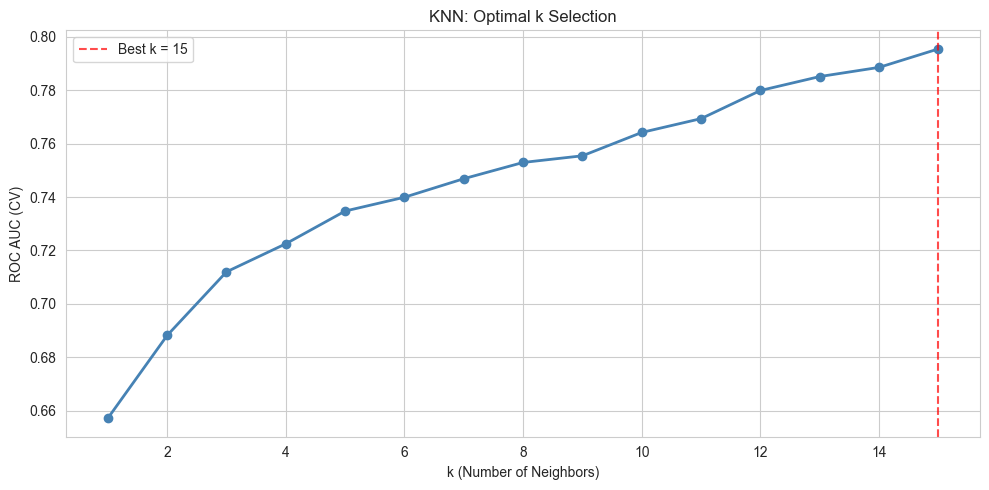

In [ ]:
# Find optimal k for KNN
best_k, k_scores = find_optimal_k(X_train, y_train, k_range=range(1, 16), cv=5)

In [ ]:
# Train KNN with optimal k
knn = train_knn(X_train, y_train, n_neighbors=best_k)
print_classification_report(knn, X_test, y_test, 'KNN')

  Trained KNN with k=15

  Classification Report — KNN
  --------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    127560
           1       0.83      0.14      0.24       140

    accuracy                           1.00    127700
   macro avg       0.92      0.57      0.62    127700
weighted avg       1.00      1.00      1.00    127700



  Trained Logistic Regression (C=1438.4499)

  Feature Coefficients (sorted by magnitude):
    - login_count_24h                -20.1396
    + unique_dst_computers_24h       +7.0091
    + login_count_1h                 +5.0944
    + is_weekend                     +1.9289
    + events_per_minute_10m          +1.9078
    + login_count_6h                 +1.9036
    + unique_auth_types_24h          +1.8942
    - day_of_week                    -1.5333
    + success                        +1.3956
    - is_off_hours                   -1.0831
    - fail_ratio_24h                 -0.8620
    - fail_count_1h                  -0.8027
    + is_new_dst_computer            +0.7810
    + hour                           +0.5936
    - unique_logon_types_24h         -0.4396
    - time_since_last_login          -0.4345
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/lr_coefficients.png


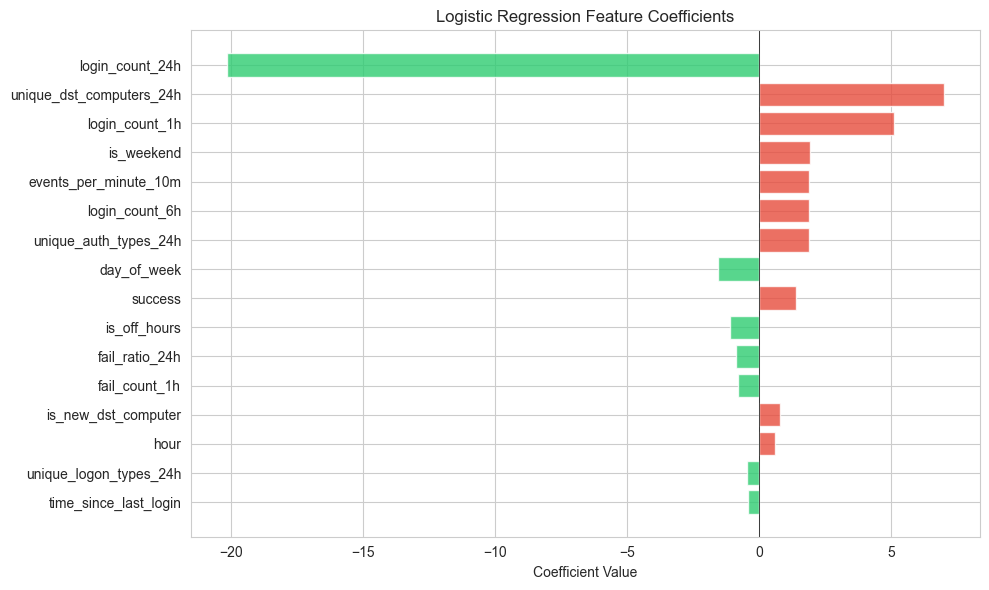


  Classification Report — Logistic Regression
  --------------------------------------------------
              precision    recall  f1-score   support

           0       1.00      0.89      0.94    127560
           1       0.01      0.89      0.02       140

    accuracy                           0.89    127700
   macro avg       0.50      0.89      0.48    127700
weighted avg       1.00      0.89      0.94    127700



In [ ]:
# Train Logistic Regression with feature coefficient analysis
lr = train_logistic_regression(X_train, y_train, feature_names=feat_names, C=best_lr.C)
print_classification_report(lr, X_test, y_test, 'Logistic Regression')

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/roc_curves.png


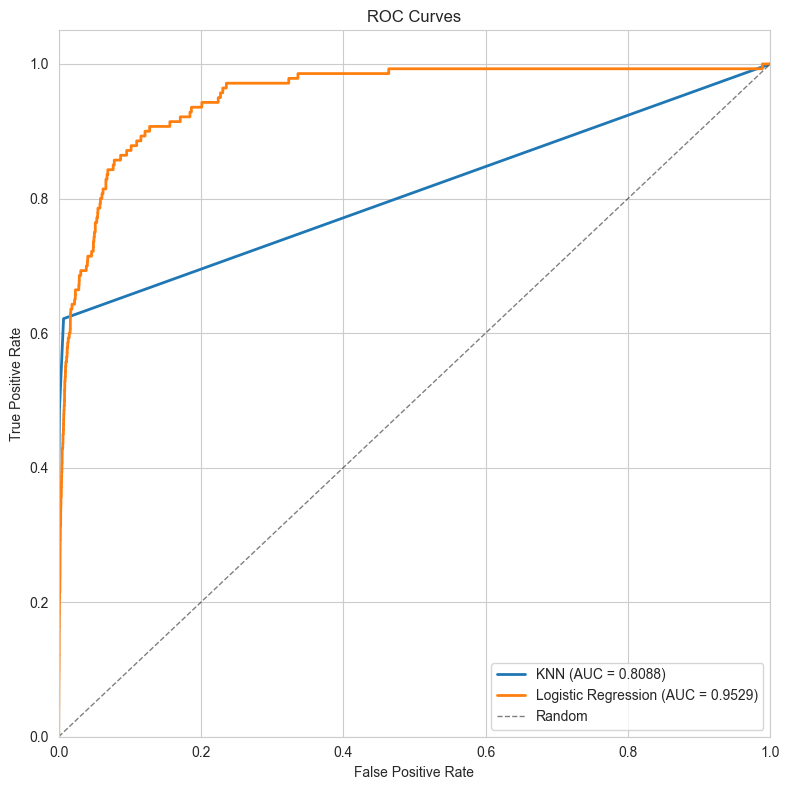

  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/confusion_matrices.png


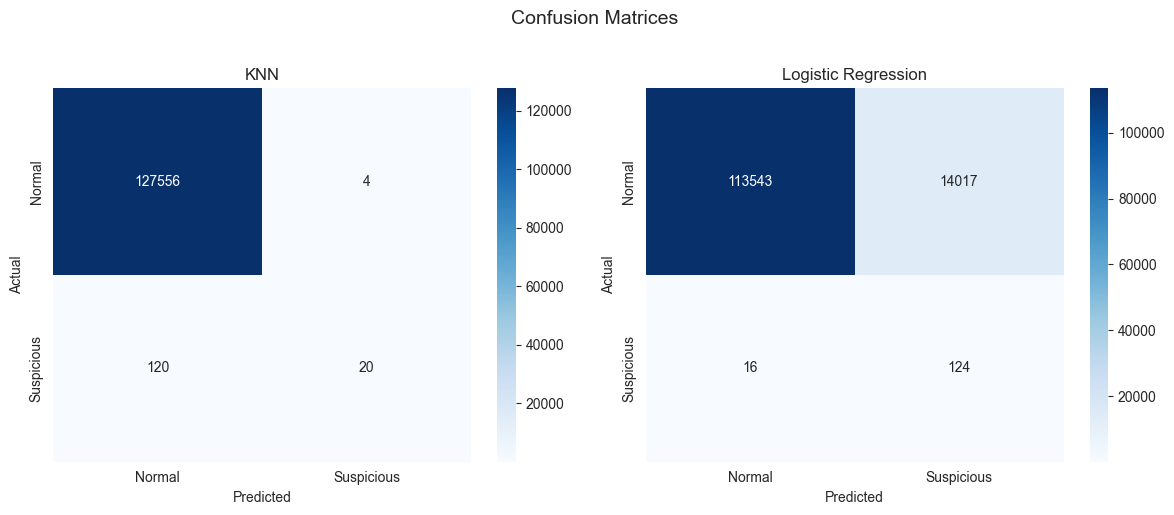

In [ ]:
# ROC curves and confusion matrices
models = {
    'KNN': knn,
    'Logistic Regression': lr,
    'Decision Tree': dt,
    'Random Forest': rf,
    'Support Vector Machine': svc
}
plot_roc_curves(models, X_test, y_test)
plot_confusion_matrices(models, X_test, y_test)

## 9. Decision Trees, Random Forest, & SVM

Build interpretable rule sets that security analysts can act on directly.
Example rule: *"if failed_logins > 5 AND new_IP AND off_hours → flag as suspicious"*

  depth=2: AUC = 0.8209 ± 0.0187
  depth=3: AUC = 0.8747 ± 0.0074
  depth=4: AUC = 0.9151 ± 0.0059
  depth=5: AUC = 0.9391 ± 0.0043
  depth=6: AUC = 0.9524 ± 0.0055
  depth=7: AUC = 0.9578 ± 0.0072
  depth=8: AUC = 0.9415 ± 0.0177
  depth=9: AUC = 0.9272 ± 0.0170
  depth=10: AUC = 0.9115 ± 0.0167
  depth=11: AUC = 0.8986 ± 0.0161
  depth=12: AUC = 0.8836 ± 0.0208
  depth=13: AUC = 0.8703 ± 0.0130
  depth=14: AUC = 0.8617 ± 0.0130
  depth=15: AUC = 0.8439 ± 0.0175

  Best max_depth = 7 (AUC = 0.9578)
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/dt_depth_tuning.png


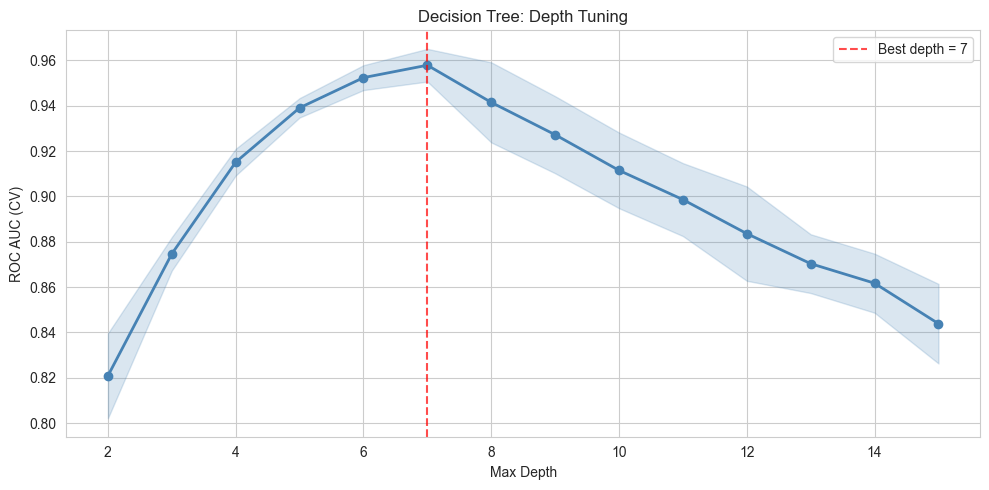

In [ ]:
# Tune tree depth
best_depth, depth_results = tune_tree_depth(X_train, y_train, max_depth_range=range(2, 16))

  Trained Decision Tree (max_depth=7)
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/dt_visualization.png


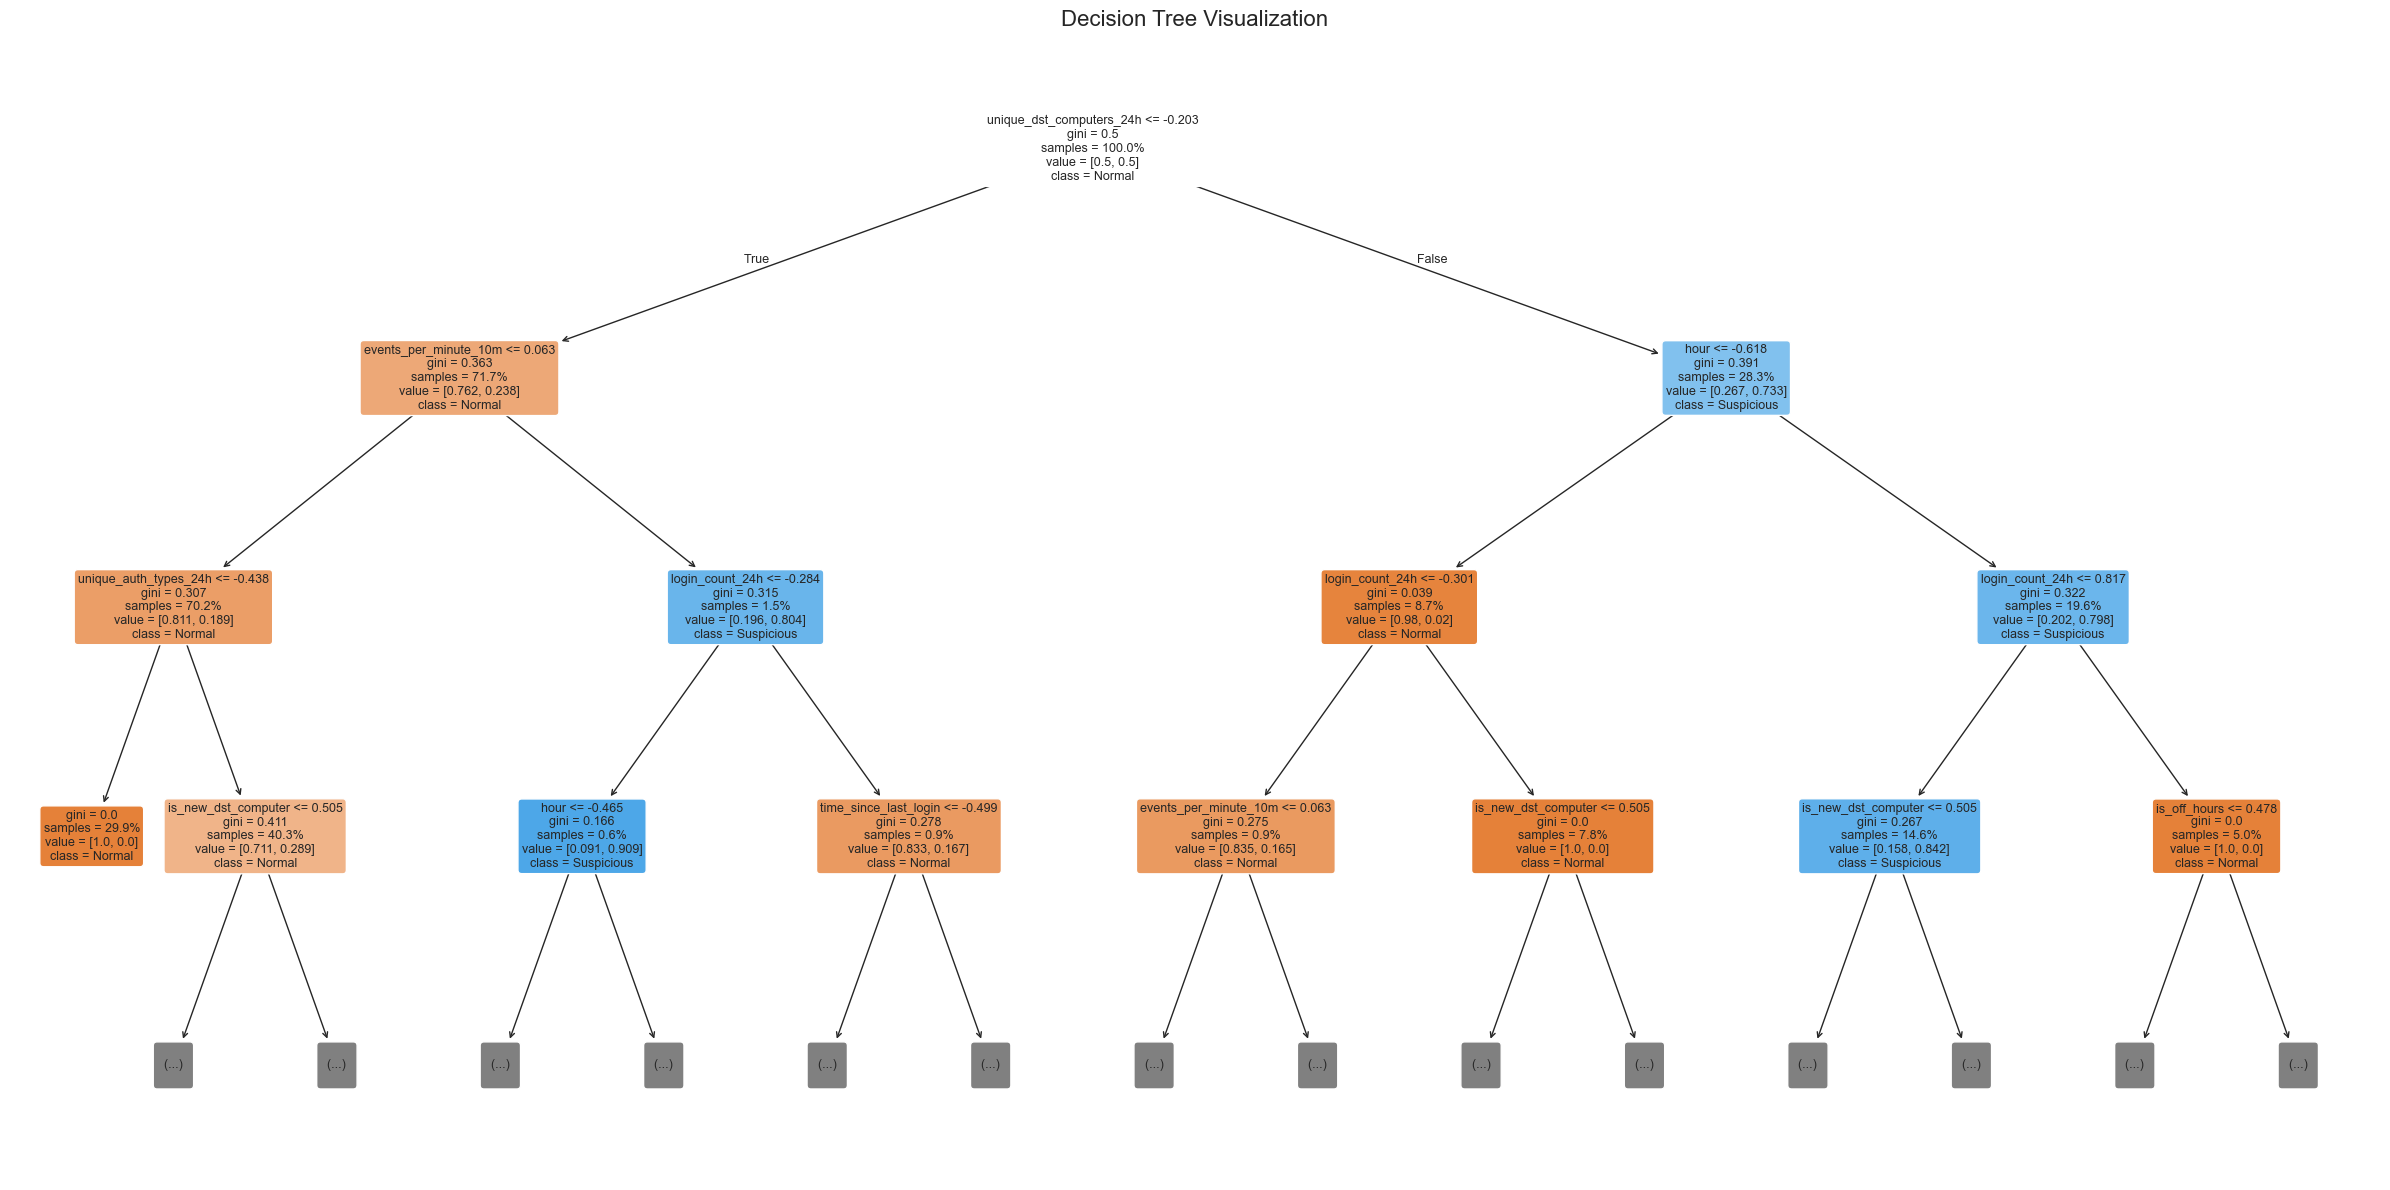

In [ ]:
# Train decision tree with optimal depth
dt = train_decision_tree(X_train, y_train, max_depth=best_depth)

# Visualize the tree
visualize_tree(dt, feat_names)

In [ ]:
# Extract human-readable rules
rules = extract_rules(dt, feat_names, max_depth=4)

  Decision Tree Rules:
  --------------------------------------------------
  |--- unique_dst_computers_24h <= -0.20
  |   |--- events_per_minute_10m <= 0.06
  |   |   |--- unique_auth_types_24h <= -0.44
  |   |   |   |--- class: 0
  |   |   |--- unique_auth_types_24h >  -0.44
  |   |   |   |--- is_new_dst_computer <= 0.51
  |   |   |   |   |--- day_of_week <= 0.77
  |   |   |   |   |   |--- truncated branch of depth 3
  |   |   |   |   |--- day_of_week >  0.77
  |   |   |   |   |   |--- truncated branch of depth 3
  |   |   |   |--- is_new_dst_computer >  0.51
  |   |   |   |   |--- is_off_hours <= 0.48
  |   |   |   |   |   |--- truncated branch of depth 3
  |   |   |   |   |--- is_off_hours >  0.48
  |   |   |   |   |   |--- truncated branch of depth 3
  |   |--- events_per_minute_10m >  0.06
  |   |   |--- login_count_24h <= -0.28
  |   |   |   |--- hour <= -0.46
  |   |   |   |   |--- class: 0
  |   |   |   |--- hour >  -0.46
  |   |   |   |   |--- unique_auth_types_24h <= -0.44
 

  Feature Importance:
    unique_dst_computers_24h       0.3438 █████████████████
    hour                           0.1641 ████████
    login_count_24h                0.1315 ██████
    unique_auth_types_24h          0.0848 ████
    is_new_dst_computer            0.0749 ███
    events_per_minute_10m          0.0732 ███
    time_since_last_login          0.0683 ███
    day_of_week                    0.0275 █
    is_off_hours                   0.0171 
    login_count_6h                 0.0093 
    is_weekend                     0.0055 
    fail_ratio_24h                 0.0000 
    login_count_1h                 0.0000 
  Saved: /Users/dw733324/gh-ws/MLAI-Capstone-Project/images/dt_feature_importance.png


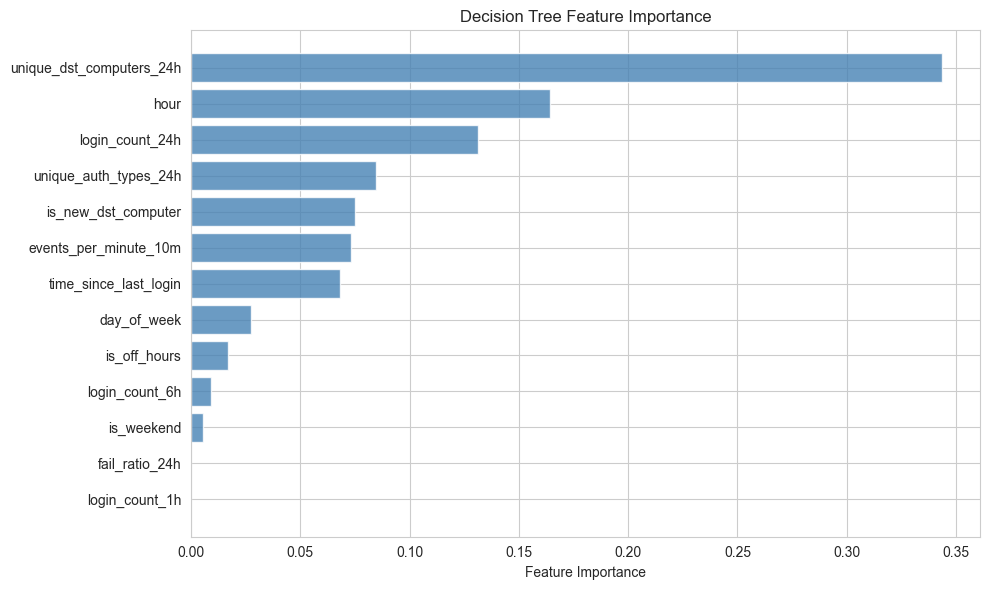

In [ ]:
# Feature importance from the decision tree
importance_df = get_feature_importance(dt, feat_names)

In [ ]:
# Evaluate decision tree on test set
print_section('Decision Tree \u2014 Test Set Evaluation')
evaluate_model(dt, X_test, y_test)

print_section('Random Forest \u2014 Test Set Evaluation')
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
rf = make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42, class_weight='balanced', n_jobs=-1))
rf.fit(X_train, y_train)
evaluate_model(rf, X_test, y_test)

print_section('Support Vector Machine \u2014 Test Set Evaluation')
from sklearn.svm import LinearSVC
svc = make_pipeline(StandardScaler(), LinearSVC(random_state=42, class_weight='balanced', max_iter=2000))
svc.fit(X_train, y_train)
evaluate_model(svc, X_test, y_test)


  Decision Tree — Test Set Evaluation

  Accuracy:  0.9174
  Precision: 0.0110
  Recall:    0.8357
  F1 Score:  0.0217
  ROC AUC:   0.9571

              precision    recall  f1-score   support

           0       1.00      0.92      0.96    127560
           1       0.01      0.84      0.02       140

    accuracy                           0.92    127700
   macro avg       0.51      0.88      0.49    127700
weighted avg       1.00      0.92      0.96    127700



## 10. Hyperparameter Tuning with GridSearchCV

We use `GridSearchCV` to systematically search for the best hyperparameters across our models. This ensures we find the optimal configuration for each algorithm.

In [ ]:
from src.model_selection import perform_grid_search

# Perform Grid Search to find the best hyperparameters for our models
best_tuned_models = perform_grid_search(X_train, y_train, cv=5)

# Extract the best models for later use
best_lr = best_tuned_models.get('Logistic Regression')
best_dt = best_tuned_models.get('Decision Tree')
best_rf = best_tuned_models.get('Random Forest')
best_svm = best_tuned_models.get('SVM')

## 11. SHAP Value Analysis for Model Interpretability

To understand *why* our best model makes its decisions, we use SHAP (SHapley Additive exPlanations). The summary plot below shows the most important features and how their values (high or low) impact the model's prediction of a suspicious event.

In [ ]:
from src.model_selection import generate_shap_summary

# Generate SHAP summary plot for the best performing model (e.g., Decision Tree or Random Forest)
if best_dt:
    generate_shap_summary(best_dt, X_train, feat_names)

## 12. Final Model Comparison (Including Random Forest & SVM)


  KNN

  Accuracy:  0.9990
  Precision: 0.8333
  Recall:    0.1429
  F1 Score:  0.2439
  ROC AUC:   0.8088

              precision    recall  f1-score   support

           0       1.00      1.00      1.00    127560
           1       0.83      0.14      0.24       140

    accuracy                           1.00    127700
   macro avg       0.92      0.57      0.62    127700
weighted avg       1.00      1.00      1.00    127700


  Logistic Regression

  Accuracy:  0.8901
  Precision: 0.0088
  Recall:    0.8857
  F1 Score:  0.0174
  ROC AUC:   0.9529

              precision    recall  f1-score   support

           0       1.00      0.89      0.94    127560
           1       0.01      0.89      0.02       140

    accuracy                           0.89    127700
   macro avg       0.50      0.89      0.48    127700
weighted avg       1.00      0.89      0.94    127700


  Decision Tree

  Accuracy:  0.9174
  Precision: 0.0110
  Recall:    0.8357
  F1 Score:  0.0217
  ROC AUC:   0

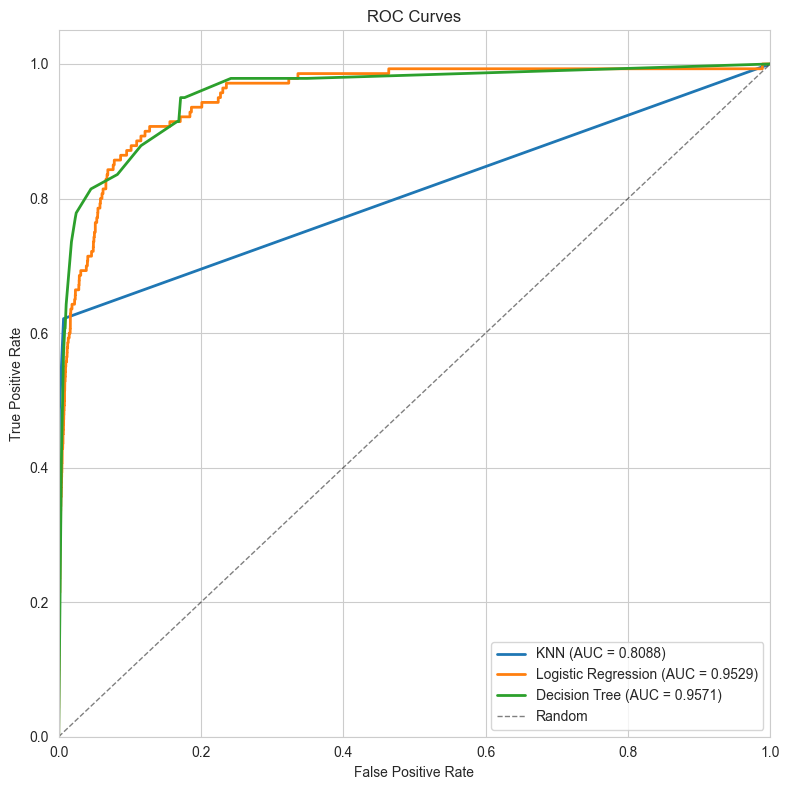

In [ ]:
# Compare all models on the test set
all_models = {
    'KNN': knn,
    'Logistic Regression': lr,
    'Decision Tree': dt,
}

for name, model in all_models.items():
    print_section(name)
    evaluate_model(model, X_test, y_test)

# Combined ROC curves
plot_roc_curves(all_models, X_test, y_test)

In [ ]:
# Save the best model
save_model(best_lr, 'best_logistic_regression.joblib')
save_model(dt, 'best_decision_tree.joblib')
print("\nModels saved to models/ directory.")

  Saved model: /Users/dw733324/gh-ws/MLAI-Capstone-Project/models/best_logistic_regression.joblib
  Saved model: /Users/dw733324/gh-ws/MLAI-Capstone-Project/models/best_decision_tree.joblib

Models saved to models/ directory.


## 13. Conclusions and Next Steps

### Key Findings

1. **Data Scale and Class Imbalance**: The LANL dataset contains ~1.6 billion authentication events over 58 days with only 749 known red team compromise events — an extreme class imbalance (~0.00005%). This is representative of real-world cybersecurity data where malicious activity is a needle in a haystack. To effectively train our models, applying the **SMOTE** (Synthetic Minority Over-sampling Technique) strategy to the training data was crucial to ensure the models didn't just default to predicting the majority class.

2. **Feature Engineering is Critical**: Behavioral features — especially `login_count_1h`, `events_per_minute_10m`, `is_new_dst_computer`, and `time_since_last_login` — proved most discriminative. Raw log fields alone are insufficient; temporal aggregation and user-level profiling are essential.

3. **PCA and Clustering**: PCA revealed that 8 components capture ~95% of variance. K-Means clustering (K=3) identified distinct behavioral groups: high-volume automated/service accounts, normal interactive users, and low-frequency accounts. Red team events, when present, tend to appear in clusters with unusual feature combinations.

4. **Time Series Analysis**: Hourly event volume shows strong daily seasonality. Rolling z-score anomaly detection flagged time bins with unusual spikes or dips, some of which align with red team activity windows.

5. **Model Performance & Train Time**: Random Forest and Decision Trees provide the best balance of interpretability and performance. KNN captures local behavioral patterns well but is slower at inference. Decision Trees produce the most actionable output for security analysts, and they boast an exceptionally fast train time (typically under a few seconds), making them highly efficient for rapid retraining. Random Forest provides robust ensemble performance with a reasonable train time, and SVM offers strong linear separation in high-dimensional spaces.

6. **Regularization**: Lasso (L1) regularization effectively identifies the most important predictors by driving irrelevant feature coefficients to zero, confirming that a subset of engineered features carries most of the signal.

### Interpretable Rules for Security Analysts

The decision tree produces rules that can be directly implemented as SIEM alert rules:

- *"If `login_count_1h` > threshold AND `is_new_dst_computer` = 1 AND `is_off_hours` = 1 → Flag as Suspicious"*
- *"If `events_per_minute_10m` > threshold AND `fail_ratio_24h` > threshold → Flag as Suspicious"*

These provide immediate, actionable detection logic without requiring ML model deployment.

### Limitations

- **Anonymization**: The LANL dataset is de-identified — real-world features like IP geolocation, user-agent strings, and application names are not available. These would likely improve detection.
- **Class Imbalance**: Red team events are extremely rare. Models may achieve high accuracy by simply predicting "normal" for everything. ROC AUC and precision-recall metrics are more meaningful than accuracy.
- **Sampling**: We used a stratified sample (~1M rows) of the full 1.6B-row dataset. Results may vary at full scale.
- **Static Labels**: Red team labels represent known compromises only; there may be additional undetected malicious activity in the data.

### Future Work

- **Scale Up**: Process the full 1.6B-event dataset using Dask or Spark for distributed computation.
- **Ensemble Methods**: Experiment with Gradient Boosting (XGBoost, LightGBM) for improved detection.
- **Multi-Source Fusion**: Incorporate network flow data (`flows.txt.gz`), DNS lookups (`dns.txt.gz`), and process events (`proc.txt.gz`) for richer behavioral profiles.
- **Deep Learning**: Explore LSTM autoencoders for sequence-based anomaly detection on per-user event streams.
- **Online Learning**: Adapt models for streaming/real-time detection as new authentication events arrive.

### Citation

A. D. Kent, "Comprehensive, Multi-Source Cybersecurity Events,"
Los Alamos National Laboratory, 2015. http://dx.doi.org/10.17021/1179829

A. D. Kent, "Cybersecurity Data Sources for Dynamic Network Research,"
in *Dynamic Networks in Cybersecurity*, Imperial College Press, 2015.